🌟 EXERCICE 1 : Small Quiz

1. Key difference between traditional ML and deep learning:
   Traditional ML often requires manual feature extraction; deep learning learns hierarchical features automatically.

2. How ANNs mimic the human brain:
   Artificial neurons receive inputs, apply weights (synaptic strength), sum them, and pass through an activation function (neuron firing). Multiple layers simulate hierarchical processing.

3. Why deep learning performs better on large datasets:
   Deep models have many parameters capturing complex patterns; large datasets prevent overfitting and improve generalization.

4. Challenges of deep learning and solutions:
   - Overfitting → use regularization (dropout, early stopping), more data.
   - High computational cost → use GPUs/TPUs, optimize architectures.
   - Lack of interpretability → use SHAP, LIME, attention maps.

5. Feature engineering and why not needed in deep learning:
   Feature engineering is manual input creation; deep learning auto

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training model (3 epochs)...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9225 - loss: 0.2704 - val_accuracy: 0.9657 - val_loss: 0.1237
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9650 - loss: 0.1167 - val_accuracy: 0.9715 - val_loss: 0.0974
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9757 - loss: 0.0794 - val_accuracy: 0.9787 - val_loss: 0.0790
Test accuracy: 0.9758

🌟 EXERCICE 4 : Forward Propagation Calculation (House price)
z (pre-activation) = 51002.1
Prediction after ReLU = 51002.1
Interpretation: The predicted house price is 51,002.1. Bias sets baseline; ReLU keeps positive values.

🌟 EXERCICE 5 (optional) : Forward & Backward Propagation in Python
Initial prediction: 36.40
Loss: 1180.9800
Updated weights: [ 2.544 39.18 ]
Updated bias: 10.49

Explanation: Gradient descent reduces error because we move parameters opposite to gradient (steepest increase).
Try modifying learning_rate or initial weights to observe 

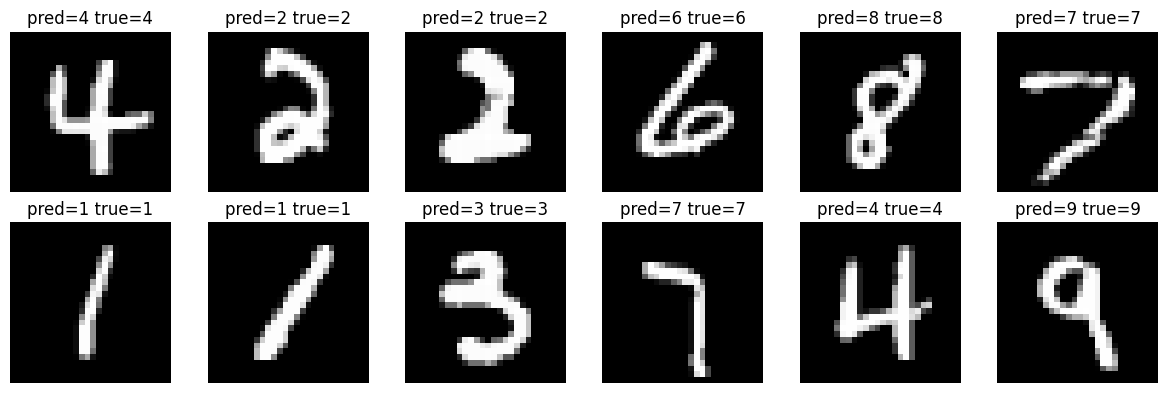

Displayed random test images with predicted and true labels.

All exercises completed successfully.


In [ ]:

"""
Exercices XP - Deep Learning fundamentals
Complete solution for all exercises (1-6)
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt


print("🌟 EXERCICE 1 : Small Quiz")

# Réponses affichées sous forme de texte
answers = """
1. Key difference between traditional ML and deep learning:
   Traditional ML often requires manual feature extraction; deep learning learns hierarchical features automatically.

2. How ANNs mimic the human brain:
   Artificial neurons receive inputs, apply weights (synaptic strength), sum them, and pass through an activation function (neuron firing). Multiple layers simulate hierarchical processing.

3. Why deep learning performs better on large datasets:
   Deep models have many parameters capturing complex patterns; large datasets prevent overfitting and improve generalization.

4. Challenges of deep learning and solutions:
   - Overfitting → use regularization (dropout, early stopping), more data.
   - High computational cost → use GPUs/TPUs, optimize architectures.
   - Lack of interpretability → use SHAP, LIME, attention maps.

5. Feature engineering and why not needed in deep learning:
   Feature engineering is manual input creation; deep learning automates this via hidden layers.

6. Role of hidden layers:
   They transform inputs into increasingly abstract representations.

7. Function of activation function:
   Introduces non-linearity; without it, stacked layers collapse to a linear model.
"""
print(answers)


print("🌟 EXERCICE 2 : Simple Perceptron Decision System")


# Parameters
W_TEMP = 0.6
W_RAIN = 0.4
BIAS = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    return 1 if s > threshold else 0

def weighted_sum(temperature_f: float, rain01: int) -> float:
    return W_TEMP * temperature_f + W_RAIN * rain01 + BIAS

# Cases
case1 = (70, 0)  # 70°F, no rain
case2 = (50, 1)  # 50°F, rain

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)
y1 = step_activation(s1)
y2 = step_activation(s2)

print(f"Case 1 (70°F, Rain=0): sum={s1}, decision={y1}")
print(f"Case 2 (50°F, Rain=1): sum={s2}, decision={y2}")
print("\nInterpretation: Both outputs are 1 (go outside). The weighted sums (44 and 32.4) exceed threshold 20. Bias +2 and high temperature weight make the decision sensitive to temperature, even with rain.")


print("🌟 EXERCICE 3 : Simple Neural Network with TensorFlow/Keras (MNIST)")


# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode
y_train_oh = to_categorical(y_train, 10)
y_test_oh = to_categorical(y_test, 10)

# Build model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train (only 3 epochs for speed, increase if needed)
print("Training model (3 epochs)...")
model.fit(x_train, y_train_oh, epochs=3, batch_size=32, validation_split=0.1, verbose=1)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


print("🌟 EXERCICE 4 : Forward Propagation Calculation (House price)")


x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0
z = x1*w1 + x2*w2 + b
y = max(0, z)  # ReLU
print(f"z (pre-activation) = {z}")
print(f"Prediction after ReLU = {y}")
print("Interpretation: The predicted house price is 51,002.1. Bias sets baseline; ReLU keeps positive values.")


print("🌟 EXERCICE 5 (optional) : Forward & Backward Propagation in Python")


# Data
x = np.array([4, 80])   # hours studied, previous score
w = np.array([0.6, 0.3])
b = 10
y_true = 85

def forward_propagation(x, w, b):
    return np.dot(x, w) + b

y_pred = forward_propagation(x, w, b)
loss = 0.5 * (y_true - y_pred) ** 2
grad_w = -(y_true - y_pred) * x
grad_b = -(y_true - y_pred)

learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

print(f"Initial prediction: {y_pred:.2f}")
print(f"Loss: {loss:.4f}")
print(f"Updated weights: {w_new}")
print(f"Updated bias: {b_new:.2f}")
print("\nExplanation: Gradient descent reduces error because we move parameters opposite to gradient (steepest increase).")
print("Try modifying learning_rate or initial weights to observe changes.")


print("🌟 EXERCICE 6 (optional) : Visualizing Predictions on MNIST")


# Use the trained model from Exercise 3
n_samples = 12
indices = np.random.choice(len(x_test), n_samples, replace=False)
x_vis = x_test[indices]
y_true_vis = y_test[indices]
y_probs = model.predict(x_vis)
y_pred_vis = np.argmax(y_probs, axis=1)

cols = 6
rows = int(np.ceil(n_samples / cols))
plt.figure(figsize=(12, 2*rows))
for i, idx in enumerate(indices):
    plt.subplot(rows, cols, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"pred={y_pred_vis[i]} true={y_true_vis[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Displayed random test images with predicted and true labels.")
print("\nAll exercises completed successfully.")